In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import joblib

RANDOM_STATE = 42

In [2]:
RAW_DATA_PATH = "../data/raw/PhiUSIIL_Phishing_URL_Dataset.csv"

raw_df = pd.read_csv(RAW_DATA_PATH)

print("Shape:", raw_df.shape)
print(raw_df[["URL", "label"]].head())

Shape: (235795, 56)
                                  URL  label
0    https://www.southbankmosaics.com      1
1            https://www.uni-mainz.de      1
2      https://www.voicefmradio.co.uk      1
3         https://www.sfnmjournal.com      1
4  https://www.rewildingargentina.org      1


In [3]:
FEATURE_DATA_PATH = "../data/processed/deployment_url_features.csv"

feature_df = pd.read_csv(FEATURE_DATA_PATH)

print("Feature dataset shape:", feature_df.shape)

feature_df.head()

Feature dataset shape: (235795, 23)


,url_length,domain_length,path_length,query_length,dot_count,hyphen_count,underscore_count,slash_count,question_count,equal_count,...,digit_count,letter_count,digit_ratio,letter_ratio,is_https,is_domain_ip,subdomain_count,suspicious_word_count,url_entropy,label
0,32,24,0,0,2,0,0,2,0,0,...,0,27,0.0,0.843750,1,0,1,1,3.929229,1
1,24,16,0,0,2,1,0,2,0,0,...,0,18,0.0,0.750000,1,0,1,0,3.970176,1
2,30,22,0,0,3,0,0,2,0,0,...,0,24,0.0,0.800000,1,0,2,0,4.164735,1
3,27,19,0,0,2,0,0,2,0,0,...,0,22,0.0,0.814815,1,0,1,0,4.060262,1
4,34,26,0,0,2,0,0,2,0,0,...,0,29,0.0,0.852941,1,0,1,0,3.917626,1


In [4]:
print("Raw rows     :", len(raw_df))
print("Feature rows :", len(feature_df))

assert len(raw_df) == len(feature_df), (
    "Raw and feature datasets are not aligned!"
)

assert np.array_equal(
    raw_df["label"].values,
    feature_df["label"].values
), "Labels are not aligned!"

print("Dataset alignment check: PASSED")

Raw rows     : 235795
Feature rows : 235795
Dataset alignment check: PASSED


In [5]:
model_df = feature_df.copy()

model_df.insert(
    0,
    "URL",
    raw_df["URL"].astype(str).values
)

print(model_df.shape)

model_df.head()

(235795, 24)


,URL,url_length,domain_length,path_length,query_length,dot_count,hyphen_count,underscore_count,slash_count,question_count,...,digit_count,letter_count,digit_ratio,letter_ratio,is_https,is_domain_ip,subdomain_count,suspicious_word_count,url_entropy,label
0,https://www.southbankmosaics.com,32,24,0,0,2,0,0,2,0,...,0,27,0.0,0.843750,1,0,1,1,3.929229,1
1,https://www.uni-mainz.de,24,16,0,0,2,1,0,2,0,...,0,18,0.0,0.750000,1,0,1,0,3.970176,1
2,https://www.voicefmradio.co.uk,30,22,0,0,3,0,0,2,0,...,0,24,0.0,0.800000,1,0,2,0,4.164735,1
3,https://www.sfnmjournal.com,27,19,0,0,2,0,0,2,0,...,0,22,0.0,0.814815,1,0,1,0,4.060262,1
4,https://www.rewildingargentina.org,34,26,0,0,2,0,0,2,0,...,0,29,0.0,0.852941,1,0,1,0,3.917626,1


In [6]:
print(
    "Total rows:",
    len(model_df)
)

print(
    "Unique URLs:",
    model_df["URL"].nunique()
)

print(
    "Repeated URL rows:",
    model_df.duplicated(
        subset=["URL"],
        keep=False
    ).sum()
)

print(
    "Number of URLs appearing more than once:",
    (
        model_df["URL"]
        .value_counts()
        .gt(1)
        .sum()
    )
)

Total rows: 235795
Unique URLs: 235370
Repeated URL rows: 850
Number of URLs appearing more than once: 425


In [7]:
url_label_counts = (
    model_df
    .groupby("URL")["label"]
    .nunique()
)

conflicting_urls = (
    url_label_counts > 1
).sum()

print(
    "URLs with conflicting labels:",
    conflicting_urls
)

URLs with conflicting labels: 0


In [8]:
model_df = (
    model_df
    .drop_duplicates(
        subset=["URL"],
        keep="first"
    )
    .reset_index(drop=True)
)

print(
    "Rows after URL deduplication:",
    len(model_df)
)

print(
    "Unique URLs after deduplication:",
    model_df["URL"].nunique()
)

Rows after URL deduplication: 235370
Unique URLs after deduplication: 235370


In [9]:
model_df["is_phishing"] = (
    1 - model_df["label"]
)

print(
    model_df[
        ["label", "is_phishing"]
    ].drop_duplicates()
)

    label  is_phishing
0       1            0
11      0            1


In [10]:
print(
    model_df["is_phishing"]
    .value_counts()
)

print()

print(
    model_df["is_phishing"]
    .value_counts(normalize=True)
    * 100
)

is_phishing
0    134850
1    100520
Name: count, dtype: int64

is_phishing
0    57.292773
1    42.707227
Name: proportion, dtype: float64


In [11]:
FEATURE_COLUMNS = [
    column
    for column in feature_df.columns
    if column != "label"
]

print(
    "Number of predictors:",
    len(FEATURE_COLUMNS)
)

print(FEATURE_COLUMNS)

Number of predictors: 22
['url_length', 'domain_length', 'path_length', 'query_length', 'dot_count', 'hyphen_count', 'underscore_count', 'slash_count', 'question_count', 'equal_count', 'ampersand_count', 'at_count', 'percent_count', 'digit_count', 'letter_count', 'digit_ratio', 'letter_ratio', 'is_https', 'is_domain_ip', 'subdomain_count', 'suspicious_word_count', 'url_entropy']


In [12]:
X = model_df[FEATURE_COLUMNS].copy()

y = model_df["is_phishing"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (235370, 22)
y shape: (235370,)


In [13]:
print(
    "Missing values in X:",
    X.isnull().sum().sum()
)

print(
    "Infinite values in X:",
    np.isinf(X).sum().sum()
)

print(
    "Target values:",
    sorted(y.unique())
)

Missing values in X: 0
Infinite values in X: 0
Target values: [np.int64(0), np.int64(1)]


In [14]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

In [15]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

In [16]:
print(
    "Training samples   :",
    len(X_train)
)

print(
    "Validation samples :",
    len(X_val)
)

print(
    "Test samples       :",
    len(X_test)
)

print()

print(
    "Total:",
    len(X_train)
    + len(X_val)
    + len(X_test)
)

Training samples   : 164759
Validation samples : 35305
Test samples       : 35306

Total: 235370


In [17]:
def show_distribution(name, target):
    counts = target.value_counts().sort_index()
    percentages = (
        target
        .value_counts(normalize=True)
        .sort_index()
        * 100
    )

    print(f"\n{name}")
    print("-" * 40)

    print("Counts:")
    print(counts)

    print("\nPercentages:")
    print(percentages)


show_distribution(
    "TRAIN",
    y_train
)

show_distribution(
    "VALIDATION",
    y_val
)

show_distribution(
    "TEST",
    y_test
)


TRAIN
----------------------------------------
Counts:
is_phishing
0    94395
1    70364
Name: count, dtype: int64

Percentages:
is_phishing
0    57.292773
1    42.707227
Name: proportion, dtype: float64

VALIDATION
----------------------------------------
Counts:
is_phishing
0    20227
1    15078
Name: count, dtype: int64

Percentages:
is_phishing
0    57.292168
1    42.707832
Name: proportion, dtype: float64

TEST
----------------------------------------
Counts:
is_phishing
0    20228
1    15078
Name: count, dtype: int64

Percentages:
is_phishing
0    57.293378
1    42.706622
Name: proportion, dtype: float64


In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_val_scaled = scaler.transform(
    X_val
)

X_test_scaled = scaler.transform(
    X_test
)

In [19]:
def evaluate_model(
    model_name,
    y_true,
    y_pred,
    y_probability
):
    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_true,
        y_probability
    )

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(
        f"Accuracy  : {accuracy:.4f}"
    )

    print(
        f"Precision : {precision:.4f}"
    )

    print(
        f"Recall    : {recall:.4f}"
    )

    print(
        f"F1 Score  : {f1:.4f}"
    )

    print(
        f"ROC-AUC   : {roc_auc:.4f}"
    )

    print("\nConfusion Matrix:")
    print(
        confusion_matrix(
            y_true,
            y_pred
        )
    )

    print("\nClassification Report:")

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=[
                "Legitimate",
                "Phishing"
            ],
            zero_division=0
        )
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": roc_auc
    }

In [20]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [21]:
logistic_val_pred = (
    logistic_model.predict(
        X_val_scaled
    )
)

logistic_val_prob = (
    logistic_model.predict_proba(
        X_val_scaled
    )[:, 1]
)

In [22]:
logistic_results = evaluate_model(
    "Logistic Regression",
    y_val,
    logistic_val_pred,
    logistic_val_prob
)

Logistic Regression
Accuracy  : 0.9931
Precision : 0.9995
Recall    : 0.9843
F1 Score  : 0.9918
ROC-AUC   : 0.9961

Confusion Matrix:
[[20219     8]
 [  236 14842]]

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      1.00      0.99     20227
    Phishing       1.00      0.98      0.99     15078

    accuracy                           0.99     35305
   macro avg       0.99      0.99      0.99     35305
weighted avg       0.99      0.99      0.99     35305



In [23]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced"
)

In [24]:
random_forest_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [25]:
rf_val_pred = (
    random_forest_model.predict(
        X_val
    )
)

rf_val_prob = (
    random_forest_model.predict_proba(
        X_val
    )[:, 1]
)

In [26]:
rf_results = evaluate_model(
    "Random Forest",
    y_val,
    rf_val_pred,
    rf_val_prob
)

Random Forest
Accuracy  : 0.9944
Precision : 0.9963
Recall    : 0.9907
F1 Score  : 0.9935
ROC-AUC   : 0.9964

Confusion Matrix:
[[20171    56]
 [  140 14938]]

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      1.00      1.00     20227
    Phishing       1.00      0.99      0.99     15078

    accuracy                           0.99     35305
   macro avg       0.99      0.99      0.99     35305
weighted avg       0.99      0.99      0.99     35305



In [27]:
hist_model = HistGradientBoostingClassifier(
    learning_rate=0.1,
    max_iter=200,
    random_state=RANDOM_STATE
)

In [28]:
hist_model.fit(
    X_train,
    y_train
)

,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",200
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing val

In [29]:
hist_val_pred = (
    hist_model.predict(
        X_val
    )
)

hist_val_prob = (
    hist_model.predict_proba(
        X_val
    )[:, 1]
)

In [30]:
hist_results = evaluate_model(
    "HistGradientBoosting",
    y_val,
    hist_val_pred,
    hist_val_prob
)

HistGradientBoosting
Accuracy  : 0.9953
Precision : 0.9991
Recall    : 0.9899
F1 Score  : 0.9945
ROC-AUC   : 0.9977

Confusion Matrix:
[[20213    14]
 [  152 14926]]

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      1.00      1.00     20227
    Phishing       1.00      0.99      0.99     15078

    accuracy                           1.00     35305
   macro avg       1.00      0.99      1.00     35305
weighted avg       1.00      1.00      1.00     35305



In [31]:
results_df = pd.DataFrame([
    logistic_results,
    rf_results,
    hist_results
])

results_df = (
    results_df
    .sort_values(
        by="F1",
        ascending=False
    )
    .reset_index(drop=True)
)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,HistGradientBoosting,0.995298,0.999063,0.989919,0.994470,0.997678
1,Random Forest,0.994448,0.996265,0.990715,0.993482,0.996419
2,Logistic Regression,0.993089,0.999461,0.984348,0.991847,0.996090


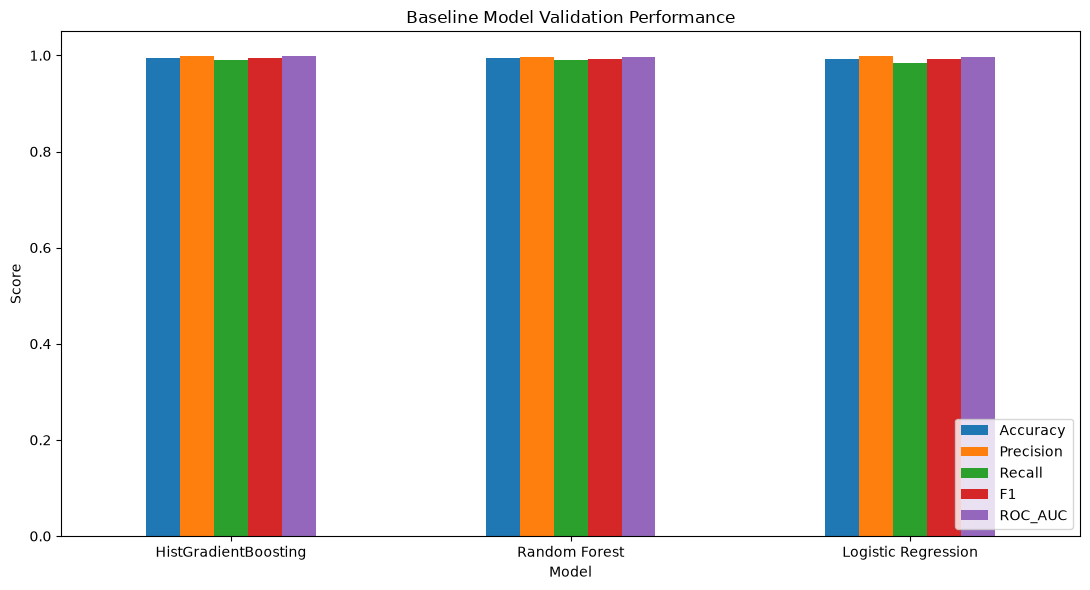

In [32]:
plot_df = (
    results_df
    .set_index("Model")[
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC_AUC"
        ]
    ]
)

plot_df.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title(
    "Baseline Model Validation Performance"
)

plt.ylabel("Score")
plt.ylim(0, 1.05)

plt.xticks(
    rotation=0
)

plt.legend(
    loc="lower right"
)

plt.tight_layout()
plt.show()

In [33]:
def plot_confusion_matrix(
    y_true,
    y_pred,
    title
):
    cm = confusion_matrix(
        y_true,
        y_pred
    )

    fig, ax = plt.subplots(
        figsize=(5, 4)
    )

    image = ax.imshow(cm)

    ax.set_title(title)

    ax.set_xlabel(
        "Predicted Class"
    )

    ax.set_ylabel(
        "Actual Class"
    )

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels([
        "Legitimate",
        "Phishing"
    ])

    ax.set_yticklabels([
        "Legitimate",
        "Phishing"
    ])

    for i in range(2):
        for j in range(2):
            ax.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    plt.tight_layout()
    plt.show()

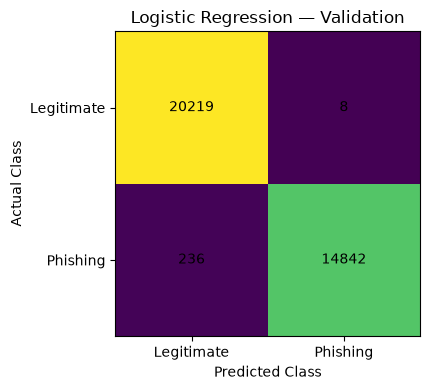

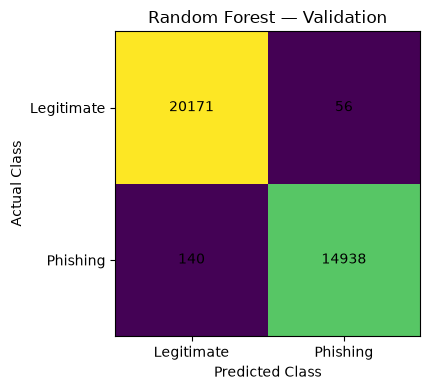

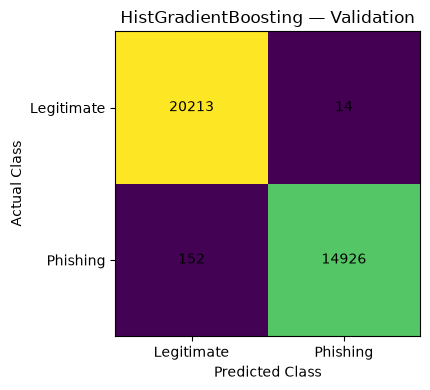

In [34]:
plot_confusion_matrix(
    y_val,
    logistic_val_pred,
    "Logistic Regression — Validation"
)

plot_confusion_matrix(
    y_val,
    rf_val_pred,
    "Random Forest — Validation"
)

plot_confusion_matrix(
    y_val,
    hist_val_pred,
    "HistGradientBoosting — Validation"
)

In [35]:
def get_false_negatives(
    y_true,
    y_pred
):
    cm = confusion_matrix(
        y_true,
        y_pred
    )

    return cm[1, 0]


print(
    "Logistic Regression FN:",
    get_false_negatives(
        y_val,
        logistic_val_pred
    )
)

print(
    "Random Forest FN:",
    get_false_negatives(
        y_val,
        rf_val_pred
    )
)

print(
    "HistGradientBoosting FN:",
    get_false_negatives(
        y_val,
        hist_val_pred
    )
)

Logistic Regression FN: 236
Random Forest FN: 140
HistGradientBoosting FN: 152


In [36]:
rf_importance = pd.DataFrame({
    "Feature": FEATURE_COLUMNS,
    "Importance":
        random_forest_model.feature_importances_
})

rf_importance = (
    rf_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

rf_importance

,Feature,Importance
0,is_https,4.438863e-01
1,slash_count,1.508691e-01
2,path_length,1.441867e-01
3,digit_count,5.221604e-02
4,digit_ratio,4.407007e-02
5,url_length,3.628866e-02
6,url_entropy,2.935467e-02
7,domain_length,2.153716e-02
8,letter_ratio,1.957465e-02
9,letter_count,1.892491e-02


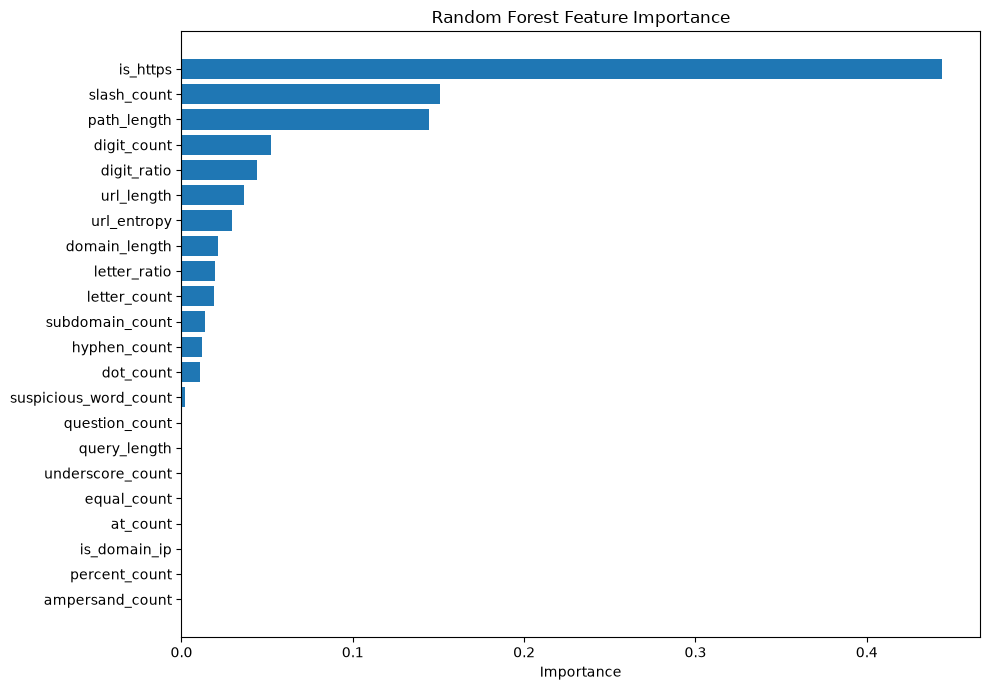

In [37]:
plt.figure(
    figsize=(10, 7)
)

plt.barh(
    rf_importance["Feature"][::-1],
    rf_importance["Importance"][::-1]
)

plt.title(
    "Random Forest Feature Importance"
)

plt.xlabel(
    "Importance"
)

plt.tight_layout()
plt.show()

In [38]:
logistic_coefficients = pd.DataFrame({
    "Feature": FEATURE_COLUMNS,
    "Coefficient":
        logistic_model.coef_[0]
})

logistic_coefficients[
    "AbsCoefficient"
] = (
    logistic_coefficients[
        "Coefficient"
    ].abs()
)

logistic_coefficients = (
    logistic_coefficients
    .sort_values(
        "AbsCoefficient",
        ascending=False
    )
)

logistic_coefficients.head(15)

,Feature,Coefficient,AbsCoefficient
7,slash_count,11.163787,11.163787
17,is_https,-5.724827,5.724827
1,domain_length,2.022423,2.022423
16,letter_ratio,-1.738320,1.738320
2,path_length,1.217583,1.217583
14,letter_count,0.994675,0.994675
0,url_length,0.972290,0.972290
19,subdomain_count,-0.605552,0.605552
20,suspicious_word_count,0.502076,0.502076
5,hyphen_count,0.395057,0.395057


In [39]:
RESULTS_PATH = (
    "../data/processed/"
    "model_validation_results.csv"
)

results_df.to_csv(
    RESULTS_PATH,
    index=False
)

print(
    "Saved:",
    RESULTS_PATH
)

Saved: ../data/processed/model_validation_results.csv


In [40]:
import os

os.makedirs(
    "../models",
    exist_ok=True
)

In [41]:
joblib.dump(
    logistic_model,
    "../models/baseline_logistic.joblib"
)

joblib.dump(
    random_forest_model,
    "../models/baseline_random_forest.joblib"
)

joblib.dump(
    hist_model,
    "../models/baseline_hist_gradient_boosting.joblib"
)

joblib.dump(
    scaler,
    "../models/baseline_scaler.joblib"
)

print(
    "Baseline models and scaler saved."
)

Baseline models and scaler saved.


In [42]:
feature_metadata = pd.DataFrame({
    "feature_order": range(
        1,
        len(FEATURE_COLUMNS) + 1
    ),
    "feature_name": FEATURE_COLUMNS
})

feature_metadata

,feature_order,feature_name
0,1,url_length
1,2,domain_length
2,3,path_length
3,4,query_length
4,5,dot_count
5,6,hyphen_count
6,7,underscore_count
7,8,slash_count
8,9,question_count
9,10,equal_count


In [43]:
feature_metadata.to_csv(
    "../data/processed/"
    "feature_metadata.csv",
    index=False
)

In [44]:
print("=" * 70)
print("PHASE 5 — BASELINE ML TRAINING SUMMARY")
print("=" * 70)

print(
    f"Rows before URL deduplication : "
    f"{len(raw_df):,}"
)

print(
    f"Rows after URL deduplication  : "
    f"{len(model_df):,}"
)

print(
    f"Predictor features            : "
    f"{len(FEATURE_COLUMNS)}"
)

print(
    f"Training samples              : "
    f"{len(X_train):,}"
)

print(
    f"Validation samples            : "
    f"{len(X_val):,}"
)

print(
    f"Test samples                  : "
    f"{len(X_test):,}"
)

print(
    "\nTarget mapping:"
)

print(
    "0 = Legitimate"
)

print(
    "1 = Phishing"
)

print(
    "\nValidation model comparison:"
)

print(
    results_df.to_string(
        index=False
    )
)

print(
    "\nFalse negatives:"
)

print(
    "Logistic Regression:",
    get_false_negatives(
        y_val,
        logistic_val_pred
    )
)

print(
    "Random Forest:",
    get_false_negatives(
        y_val,
        rf_val_pred
    )
)

print(
    "HistGradientBoosting:",
    get_false_negatives(
        y_val,
        hist_val_pred
    )
)

print(
    "\nTEST SET STATUS: UNTOUCHED"
)

PHASE 5 — BASELINE ML TRAINING SUMMARY
Rows before URL deduplication : 235,795
Rows after URL deduplication  : 235,370
Predictor features            : 22
Training samples              : 164,759
Validation samples            : 35,305
Test samples                  : 35,306

Target mapping:
0 = Legitimate
1 = Phishing

Validation model comparison:
               Model  Accuracy  Precision   Recall       F1  ROC_AUC
HistGradientBoosting  0.995298   0.999063 0.989919 0.994470 0.997678
       Random Forest  0.994448   0.996265 0.990715 0.993482 0.996419
 Logistic Regression  0.993089   0.999461 0.984348 0.991847 0.996090

False negatives:
Logistic Regression: 236
Random Forest: 140
HistGradientBoosting: 152

TEST SET STATUS: UNTOUCHED
